In [208]:
import pandas as pd
df=pd.read_excel("/content/RS Data for Python.xlsx")

In [209]:
df.head()

,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,Sales,FirstName,...,ProductName,Category,SubCategory,UnitPrice,CostPrice,Profit,Profit %,StoreName,City.1,Region
0,T00039,2024-10-13,C200,P001,S002,3,0.0,Cash,5021.070,Ronald,...,Like Camera,Electronics,Camera,1673.69,1323.38,350.31,0.264709,MegaMart Peckmouth,Peckmouth,East
1,T00054,2024-01-29,C166,P001,S004,4,0.0,Cash,6694.760,Meagan,...,Like Camera,Electronics,Camera,1673.69,1323.38,350.31,0.264709,MegaMart Brianahaven,Brianahaven,North
2,T00126,2023-10-21,C006,P001,S004,3,0.0,Cash,5021.070,Danny,...,Like Camera,Electronics,Camera,1673.69,1323.38,350.31,0.264709,MegaMart Brianahaven,Brianahaven,North
3,T00289,2024-05-25,C197,P001,S005,4,0.0,Mobile Money,6694.760,Matthew,...,Like Camera,Electronics,Camera,1673.69,1323.38,350.31,0.264709,MegaMart Johnmouth,Johnmouth,East
4,T00290,2024-10-07,C161,P001,S005,3,0.1,Mobile Money,4518.963,Michael,...,Like Camera,Electronics,Camera,1673.69,1323.38,350.31,0.264709,MegaMart Johnmouth,Johnmouth,East


In [210]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  5000 non-null   object        
 1   Date           5000 non-null   datetime64[ns]
 2   CustomerID     5000 non-null   object        
 3   ProductID      5000 non-null   object        
 4   StoreID        5000 non-null   object        
 5   Quantity       5000 non-null   int64         
 6   Discount       5000 non-null   float64       
 7   PaymentMethod  5000 non-null   object        
 8   Sales          5000 non-null   float64       
 9   FirstName      5000 non-null   object        
 10  LastName       5000 non-null   object        
 11  Gender         5000 non-null   object        
 12  BirthDate      5000 non-null   datetime64[ns]
 13  City           5000 non-null   object        
 14  JoinDate       5000 non-null   datetime64[ns]
 15  ProductName    5000 n

In [211]:
df.describe()
df.isnull().sum()

,0
TransactionID,0
Date,0
CustomerID,0
ProductID,0
StoreID,0
Quantity,0
Discount,0
PaymentMethod,0
Sales,0
FirstName,0


In [212]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [213]:
import numpy as np
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [214]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [215]:
df['Date'] = pd.to_datetime(df['Date'])
df['BirthDate'] = pd.to_datetime(df['BirthDate'])
df['JoinDate'] = pd.to_datetime(df['JoinDate'])

df['CustomerAge'] = (
    pd.Timestamp.now().year -
    df['BirthDate'].dt.year
)

df['CustomerTenure'] = (
    pd.Timestamp.now().year -
    df['JoinDate'].dt.year
)

df['SalesMonth'] = df['Date'].dt.month

In [216]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Sales'] < lower) |
    (df['Sales'] > upper)
]

print(outliers.shape)

(10, 28)


In [217]:
df = df[
    (df['Sales'] >= lower) &
    (df['Sales'] <= upper)
]

In [218]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

df['PaymentMethod'] = encoder.fit_transform(
    df['PaymentMethod']
)


In [219]:
df = pd.get_dummies(
    df,
    columns=['Category', 'Region']
)

In [220]:
drop_cols = [
    'TransactionID',
    'FirstName',
    'LastName'
]

df = df.drop(columns=drop_cols)


In [221]:
df['Quantity'] = df['Quantity'].astype('int16')
df['Sales'] = df['Sales'].astype('float32')
df['CustomerAge'] = df['CustomerAge'].astype('int16')
df['CustomerTenure'] = df['CustomerTenure'].astype('int16')

In [222]:
print(df.info())
print(df.isnull().sum())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 4990 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  4990 non-null   datetime64[ns]
 1   CustomerID            4990 non-null   object        
 2   ProductID             4990 non-null   object        
 3   StoreID               4990 non-null   object        
 4   Quantity              4990 non-null   int16         
 5   Discount              4990 non-null   float64       
 6   PaymentMethod         4990 non-null   int64         
 7   Sales                 4990 non-null   float32       
 8   Gender                4990 non-null   int64         
 9   BirthDate             4990 non-null   datetime64[ns]
 10  City                  4990 non-null   object        
 11  JoinDate              4990 non-null   datetime64[ns]
 12  ProductName           4990 non-null   object        
 13  SubCategory           4

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print(df.head())

        Date CustomerID ProductID StoreID  Quantity  Discount  PaymentMethod  \
0 2024-10-13       C200      P001    S002         3       0.0              1   
1 2024-01-29       C166      P001    S004         4       0.0              1   
2 2023-10-21       C006      P001    S004         3       0.0              1   
3 2024-05-25       C197      P001    S005         4       0.0              3   
4 2024-10-07       C161      P001    S005         3       0.1              3   

         Sales  Gender  BirthDate  ... CustomerAge CustomerTenure SalesMonth  \
0  5021.069824       1 2001-12-24  ...          25              1         10   
1  6694.759766       0 2001-05-13  ...          25              3          1   
2  5021.069824       1 1986-10-03  ...          40              4         10   
3  6694.759766       1 1957-09-23  ...          69              6          5   
4  4518.962891       1 1963-01-19  ...          63              3         10   

  Category_Electronics  Category_Fashi

In [224]:
total_sales = df['Sales'].sum()
print(total_sales)

total_profit = df['Profit'].sum()
print(total_profit)

14204270.0
1668026.33


In [225]:
aov = df['Sales'].mean()
print(aov)

2846.547


In [226]:
profit_margin = (
    df['Profit'].sum() /
    df['Sales'].sum()
) * 100

print(profit_margin)

11.743133086036806


In [227]:
# Reconstruct 'Category' and 'Region' for analysis
# Assuming only one category_XXX and one Region_YYY is True per row
df['Reconstructed_Category'] = df[['Category_Electronics', 'Category_Fashion', 'Category_Groceries']].idxmax(axis=1).str.replace('Category_', '')
df['Reconstructed_Region'] = df[['Region_East', 'Region_North', 'Region_South', 'Region_West']].idxmax(axis=1).str.replace('Region_', '')

category_sales = df.groupby('Reconstructed_Category')['Sales'].sum()

print(category_sales)

Reconstructed_Category
Electronics    6219285.000
Fashion        6232279.500
Groceries      1752706.125
Name: Sales, dtype: float32


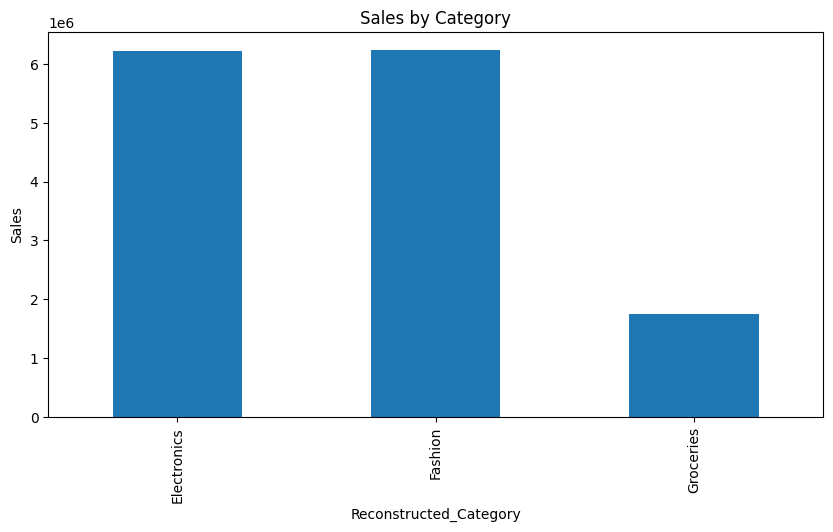

In [228]:
category_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

In [229]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

In [230]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1     1202583.625
2     1058134.750
3     1129948.625
4     1269522.125
5     1198751.125
6     1314571.625
7     1156012.625
8     1096119.500
9     1116470.250
10    1213248.250
11    1151862.000
12    1297046.000
Name: Sales, dtype: float32


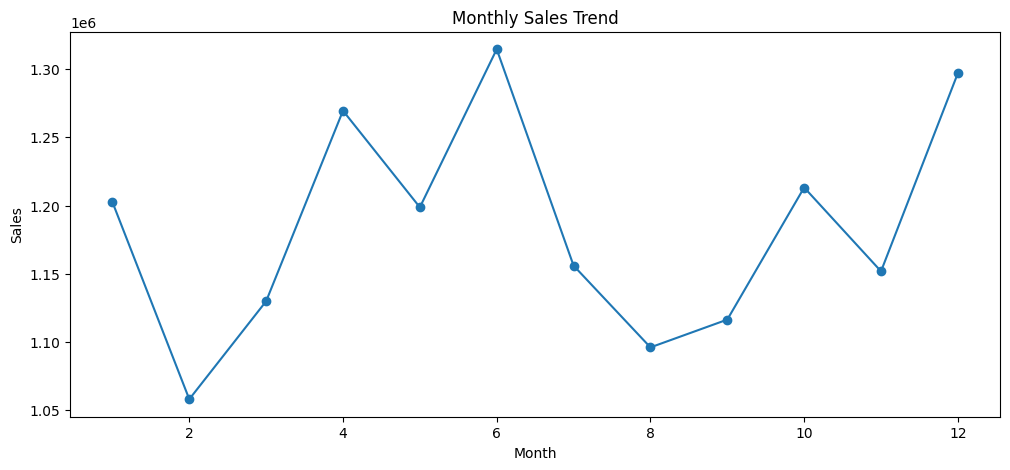

In [231]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

In [232]:
# Reconstruct 'Region' for analysis
# Assuming only one Region_YYY is True per row
df['Reconstructed_Region'] = df[['Region_East', 'Region_North', 'Region_South', 'Region_West']].idxmax(axis=1).str.replace('Region_', '')

region_sales = df.groupby('Reconstructed_Region')['Sales'].sum()
print(region_sales)

Reconstructed_Region
East     5532337.5
North    2881174.5
South    2870351.5
West     2920407.0
Name: Sales, dtype: float32


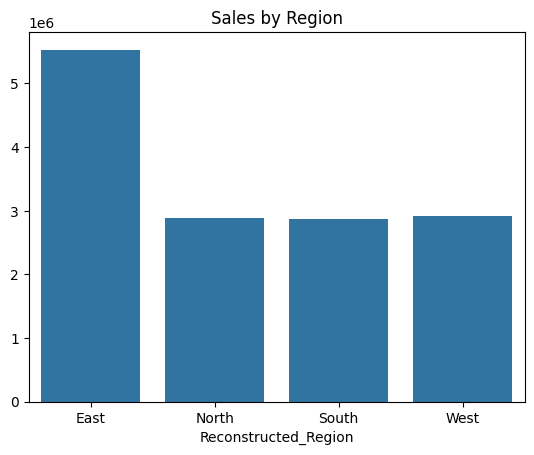

In [233]:
sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title('Sales by Region')

plt.show()

In [234]:
top_customers = (
    df.groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

CustomerID
C012    117085.765625
C110    112255.429688
C085    111867.562500
C077    102378.929688
C042    102068.046875
C168    101478.726562
C186    101239.398438
C029    100719.710938
C102     99498.945312
C033     97397.937500
Name: Sales, dtype: float32


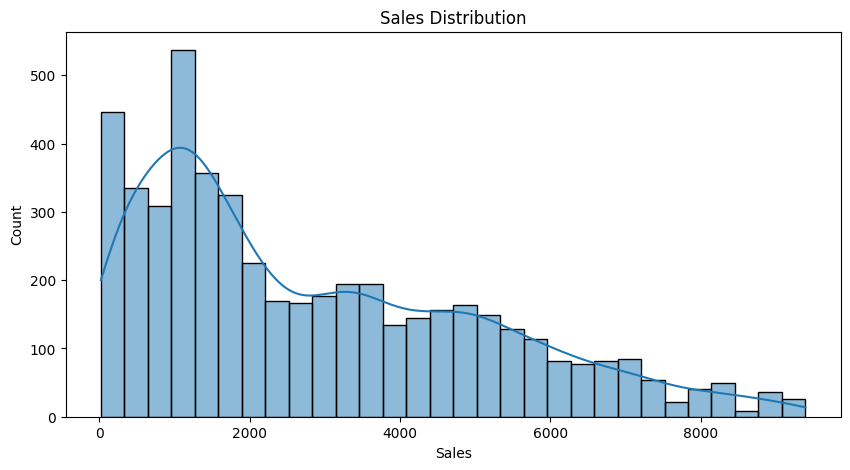

In [235]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Sales'],
    bins=30,
    kde=True
)

plt.title('Sales Distribution')

plt.show()

In [236]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                      Quantity  Discount  PaymentMethod     Sales    Gender  \
Quantity              1.000000  0.001761       0.003979  0.594881  0.008291   
Discount              0.001761  1.000000      -0.000884 -0.070817  0.014713   
PaymentMethod         0.003979 -0.000884       1.000000 -0.022335 -0.008592   
Sales                 0.594881 -0.070817      -0.022335  1.000000  0.005447   
Gender                0.008291  0.014713      -0.008592  0.005447  1.000000   
UnitPrice            -0.009558  0.006408      -0.033485  0.715734 -0.007975   
CostPrice            -0.011261  0.005236      -0.035892  0.690566 -0.012970   
Profit               -0.004017  0.007459      -0.021399  0.615224  0.004012   
Profit %              0.010564  0.004888       0.014214 -0.160754  0.007358   
CustomerAge           0.005640 -0.015146      -0.000772 -0.009751  0.042872   
CustomerTenure       -0.003413 -0.015583      -0.027094  0.012154  0.192611   
SalesMonth            0.000152  0.008321      -0.013

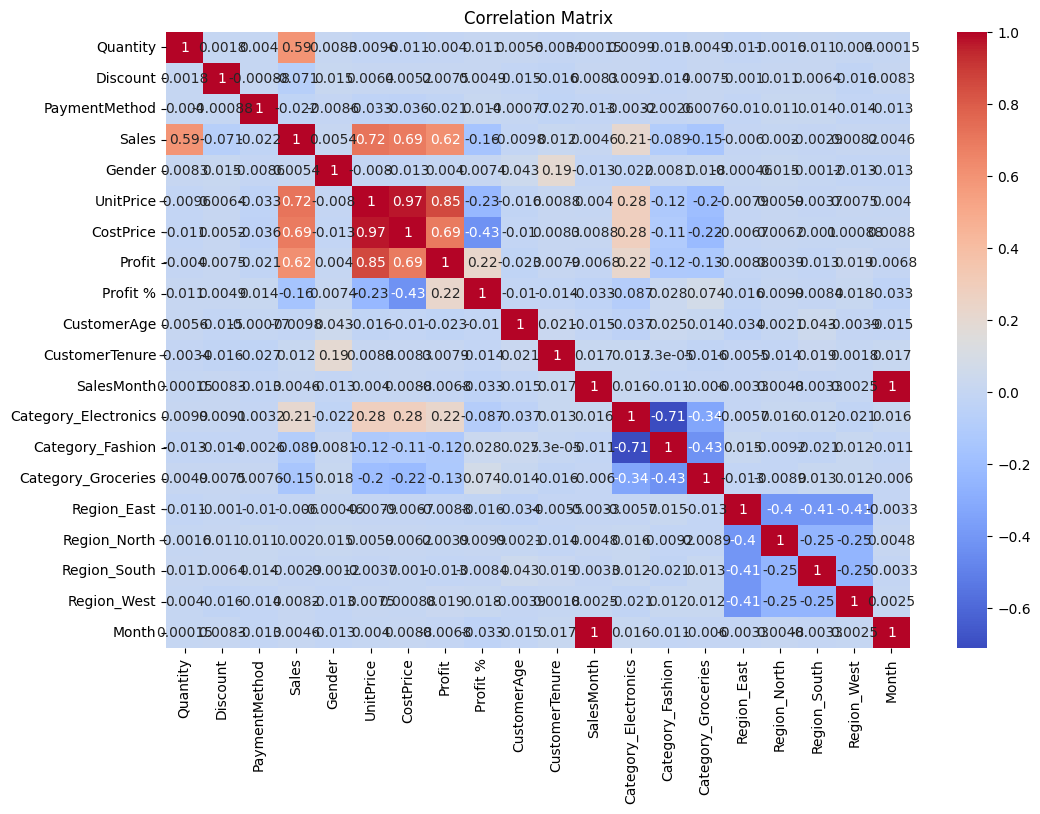

In [237]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

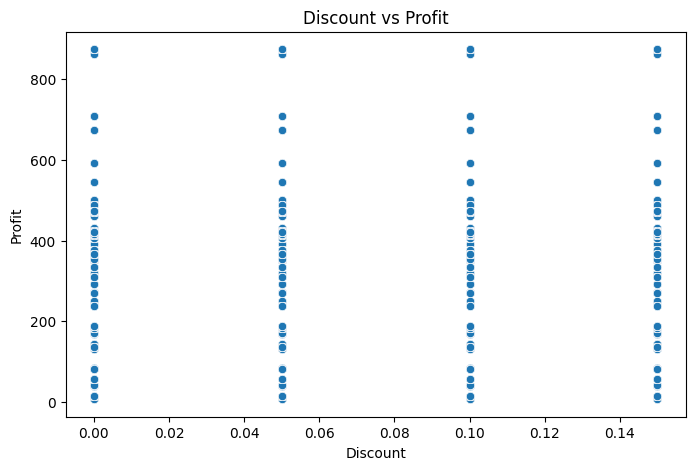

In [238]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title('Discount vs Profit')

plt.show()

In [239]:
top_products = (
    df.groupby('ProductName')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

ProductName
And Footwear          585613.00000
Set Dairy             573777.06250
Traditional Laptop    521031.00000
Book Television       507396.09375
Beat Accessories      498224.75000
Piece Headphones      497149.71875
Like Camera           482608.50000
Road Clothing         479596.90625
Present Television    477913.40625
Four Accessories      471228.34375
Name: Sales, dtype: float32


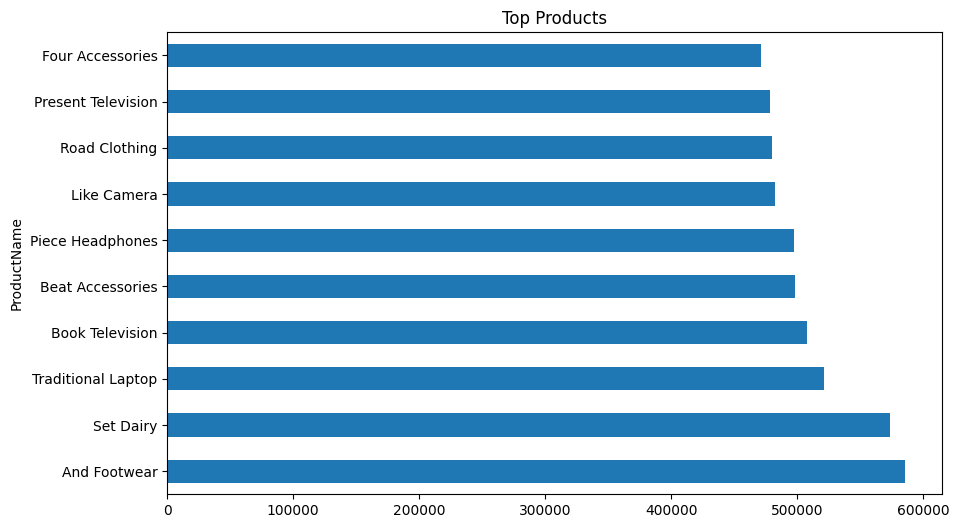

In [240]:
top_products.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top Products')

plt.show()

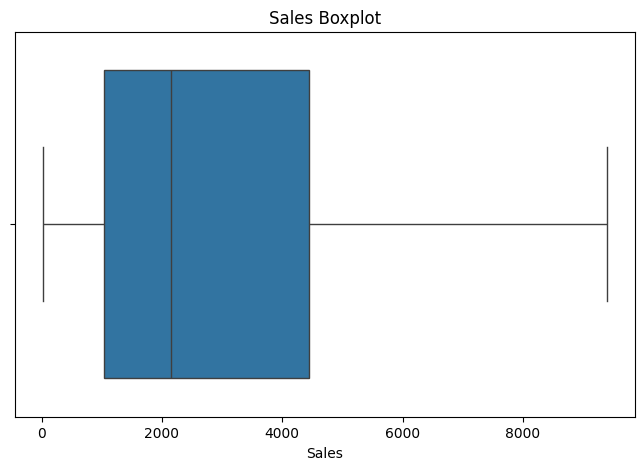

In [241]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Sales']
)

plt.title('Sales Boxplot')

plt.show()

In [242]:
pivot = pd.pivot_table(
    df,
    values='Profit',
    index='Reconstructed_Category',
    columns='Reconstructed_Region',
    aggfunc='sum'
)

print(pivot)

Reconstructed_Region         East      North      South       West
Reconstructed_Category                                            
Electronics             270606.49  147505.43  150334.22  140239.82
Fashion                 296148.44  145431.36  135366.62  152333.19
Groceries                82315.20   45940.68   47690.53   54114.35


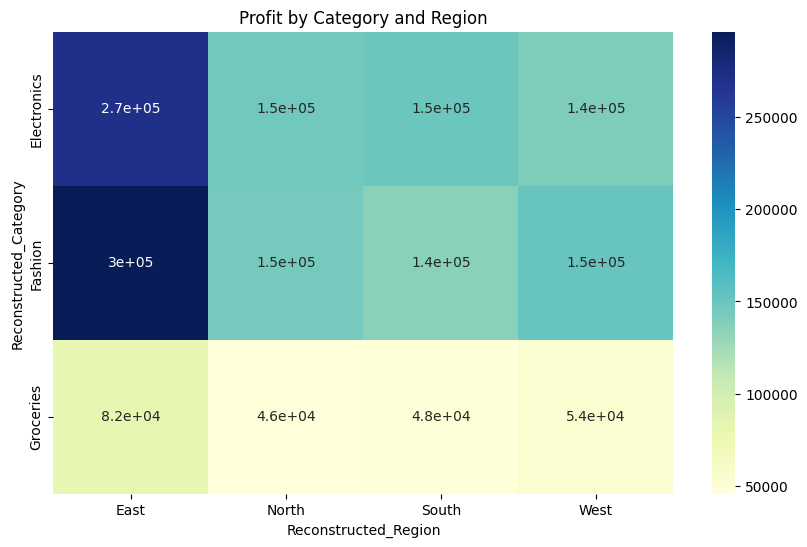

In [243]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title('Profit by Category and Region')

plt.show()

In [244]:
fig = px.bar(
    grouped_sales,
    x='Reconstructed_Category',
    y='Sales',
    color='Reconstructed_Region',
    title='Interactive Sales Dashboard'
)

fig.show()

In [245]:
mean_sales = df['Sales'].mean()

print(mean_sales)

2846.547


In [246]:
median_sales = df['Sales'].median()

print(median_sales)

2149.416015625


In [247]:
mode_category = df['Reconstructed_Category'].mode()

print(mode_category)

0    Fashion
Name: Reconstructed_Category, dtype: object


In [248]:
variance_sales = df['Sales'].var()

print(variance_sales)

5049133.0


In [249]:
std_sales = df['Sales'].std()

print(std_sales)

2247.027587890625


In [250]:
card_prob = (
    (df['PaymentMethod'] == 'Card').sum()
    / len(df)
)

print(card_prob)

0.0


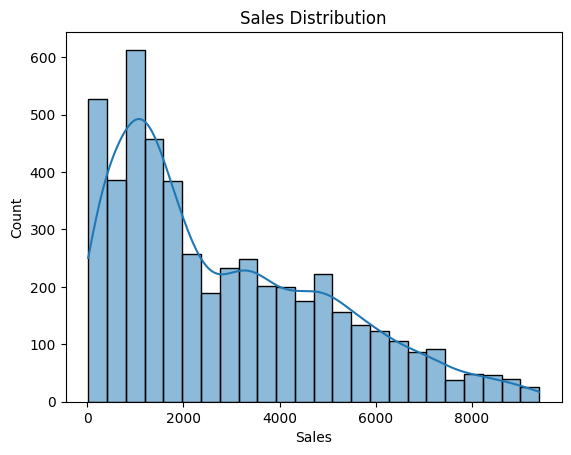

In [251]:
sns.histplot(
    df['Sales'],
    kde=True
)

plt.title('Sales Distribution')

plt.show()

In [252]:
sample_df = df.sample(
    n=500,
    random_state=42
)

In [253]:
from scipy.stats import ttest_ind

male_sales = df[df['Gender']==1]['Sales']
female_sales = df[df['Gender']==0]['Sales']

t_stat, p_value = ttest_ind(
    male_sales,
    female_sales
)

print(p_value)

0.7004659617716315


In [254]:
df['Date'] = pd.to_datetime(df['Date'])
df['BirthDate'] = pd.to_datetime(df['BirthDate'])
df['JoinDate'] = pd.to_datetime(df['JoinDate'])

In [255]:
df['Year'] = df['Date'].dt.year

In [256]:
df['Month'] = df['Date'].dt.month

In [257]:
df['Day'] = df['Date'].dt.day

In [258]:
df['Weekday'] = df['Date'].dt.day_name()

In [259]:
df['Quarter'] = df['Date'].dt.quarter

In [260]:
df['CustomerAge'] = (
    pd.Timestamp.now().year -
    df['BirthDate'].dt.year
)

In [261]:
df['CustomerTenure'] = (
    pd.Timestamp.now().year -
    df['JoinDate'].dt.year
)

In [262]:
df['ProfitMargin'] = (
    df['Profit'] / df['Sales']
) * 100

In [263]:
df['DiscountApplied'] = np.where(
    df['Discount'] > 0,
    1,
    0
)

In [264]:
customer_avg_spend = (
    df.groupby('CustomerID')['Sales']
    .mean()
)

print(customer_avg_spend.head())

CustomerID
C001    2963.079590
C002    1892.096924
C003    3388.228760
C004    2238.166260
C005    2378.306152
Name: Sales, dtype: float32


In [265]:
df['AvgCustomerSpend'] = (
    df.groupby('CustomerID')['Sales']
    .transform('mean')
)

In [266]:
df['ProductAvgSales'] = (
    df.groupby('ProductName')['Sales']
    .transform('mean')
)

In [267]:
df['ProductTotalQuantity'] = (
    df.groupby('ProductName')['Quantity']
    .transform('sum')
)

In [268]:
df['StoreAvgSales'] = (
    df.groupby('StoreID')['Sales']
    .transform('mean')
)

In [269]:
df = df.sort_values('Date')

df['RollingSalesMean'] = (
    df['Sales']
    .rolling(window=7)
    .mean()
)

In [270]:
df['PreviousSales'] = df['Sales'].shift(1)

In [271]:
freq = df['ProductName'].value_counts()

df['ProductFreq'] = (
    df['ProductName']
    .map(freq)
)

In [272]:
df['Discount_Profit'] = (
    df['Discount'] * df['Profit']
)

In [273]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'Quantity',
    'Sales',
    'Profit',
    'CustomerAge',
    'CustomerTenure'
]

df[scale_cols] = scaler.fit_transform(
    df[scale_cols]
)

In [274]:
corr = df.corr(numeric_only=True)

print(corr['Sales'].sort_values(
    ascending=False
))

Sales                   1.000000
ProductAvgSales         0.719193
UnitPrice               0.715734
CostPrice               0.690566
Profit                  0.615224
Quantity                0.594881
RollingSalesMean        0.374684
Discount_Profit         0.290375
Category_Electronics    0.208464
AvgCustomerSpend        0.169875
ProductFreq             0.103136
ProductTotalQuantity    0.077819
StoreAvgSales           0.034209
Day                     0.018517
PreviousSales           0.014834
CustomerTenure          0.012154
Year                    0.011704
Region_West             0.008172
Quarter                 0.006440
Gender                  0.005447
SalesMonth              0.004616
Month                   0.004616
Region_North            0.002001
Region_South           -0.002927
Region_East            -0.005968
CustomerAge            -0.009751
PaymentMethod          -0.022335
DiscountApplied        -0.049433
Discount               -0.070817
Category_Fashion       -0.089280
Category_G

           Date CustomerID ProductID StoreID  Quantity  Discount  \
661  2023-09-10       C082      P008    S001 -1.410528      0.15   
2353 2023-09-10       C156      P024    S005 -0.700211      0.10   
1097 2023-09-10       C066      P012    S005  1.430741      0.05   
3793 2023-09-10       C194      P038    S004 -1.410528      0.15   
3390 2023-09-10       C166      P034    S001  0.010107      0.05   

      PaymentMethod     Sales  Gender  BirthDate  ... ProfitMargin  \
661               3 -1.225398       1 2003-05-11  ...    41.998434   
2353              2 -0.075311       1 1956-11-28  ...    25.186959   
1097              1  1.255394       0 1985-09-14  ...     6.614403   
3793              2 -1.128114       1 2000-09-02  ...    26.195091   
3390              3 -0.723962       0 2001-05-13  ...    14.917096   

     DiscountApplied AvgCustomerSpend ProductAvgSales  ProductTotalQuantity  \
661                1      2569.452881      312.759827                   298   
2353        

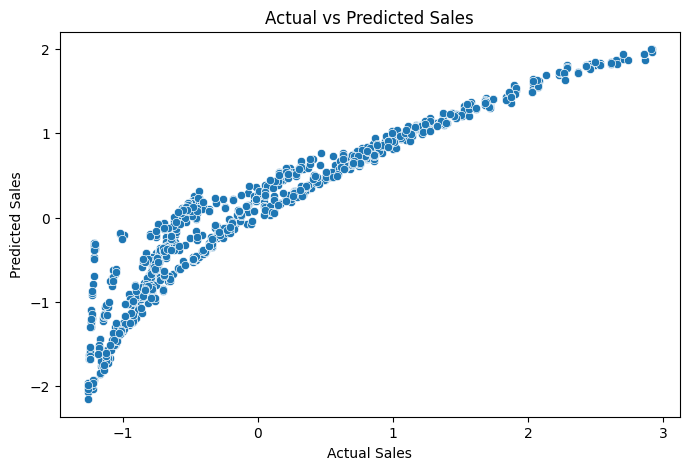

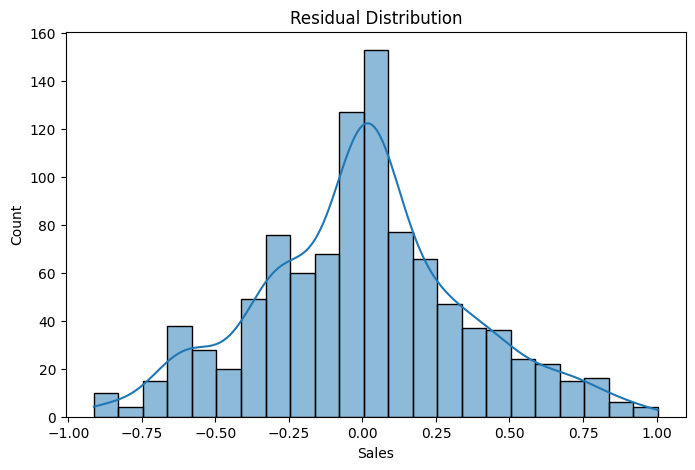

            Feature  Coefficient
0          Quantity     0.592619
1          Discount    -1.285132
2         UnitPrice     0.000858
3         CostPrice    -0.000002
4            Profit     0.000004
5       CustomerAge    -0.004303
6    CustomerTenure     0.007187
7  AvgCustomerSpend     0.000033
8   ProductAvgSales     0.000134
9     StoreAvgSales     0.000183

========== INTERPRETATION ==========

Positive coefficient:
Feature increases sales.

Negative coefficient:
Feature decreases sales.


Train Score: 0.880782152993677
Test Score : 0.881784105254197

Day 6 Completed Successfully


In [275]:
# ================================
# DAY 6 — MACHINE LEARNING FOUNDATIONS
# ================================

# ========= IMPORTS =========

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print(df.head())

# ================================
# FEATURE SELECTION
# ================================

# Selecting useful features

features = [
    'Quantity',
    'Discount',
    'UnitPrice',
    'CostPrice',
    'Profit',
    'CustomerAge',
    'CustomerTenure',
    'AvgCustomerSpend',
    'ProductAvgSales',
    'StoreAvgSales'
]

X = df[features]

# Target Variable
y = df['Sales']

# ================================
# TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ================================
# MODEL BUILDING
# ================================

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# ================================
# PREDICTIONS
# ================================

predictions = model.predict(X_test)

print(predictions[:5])

# ================================
# EVALUATION
# ================================

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ================================
# ACTUAL VS PREDICTED
# ================================

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

print(results.head())

# ================================
# VISUALIZATION
# ================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# ================================
# RESIDUAL ANALYSIS
# ================================

residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# ================================
# FEATURE IMPORTANCE
# ================================

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(coefficients)

# ================================
# MODEL INTERPRETATION
# ================================

print("\n========== INTERPRETATION ==========")

print("""
Positive coefficient:
Feature increases sales.

Negative coefficient:
Feature decreases sales.
""")

# ================================
# OVERFITTING CHECK
# ================================

train_score = model.score(X_train, y_train)

test_score = model.score(X_test, y_test)

print("\nTrain Score:", train_score)
print("Test Score :", test_score)

# ================================
# SAVING RESULTS
# ================================

results.to_csv(
    'day6_predictions.csv',
    index=False
)

print("\nDay 6 Completed Successfully")

           Date CustomerID ProductID StoreID  Quantity  Discount  \
661  2023-09-10       C082      P008    S001 -1.410528      0.15   
2353 2023-09-10       C156      P024    S005 -0.700211      0.10   
1097 2023-09-10       C066      P012    S005  1.430741      0.05   
3793 2023-09-10       C194      P038    S004 -1.410528      0.15   
3390 2023-09-10       C166      P034    S001  0.010107      0.05   

      PaymentMethod     Sales  Gender  BirthDate  ... ProfitMargin  \
661               3 -1.225398       1 2003-05-11  ...    41.998434   
2353              2 -0.075311       1 1956-11-28  ...    25.186959   
1097              1  1.255394       0 1985-09-14  ...     6.614403   
3793              2 -1.128114       1 2000-09-02  ...    26.195091   
3390              3 -0.723962       0 2001-05-13  ...    14.917096   

     DiscountApplied AvgCustomerSpend ProductAvgSales  ProductTotalQuantity  \
661                1      2569.452881      312.759827                   298   
2353        

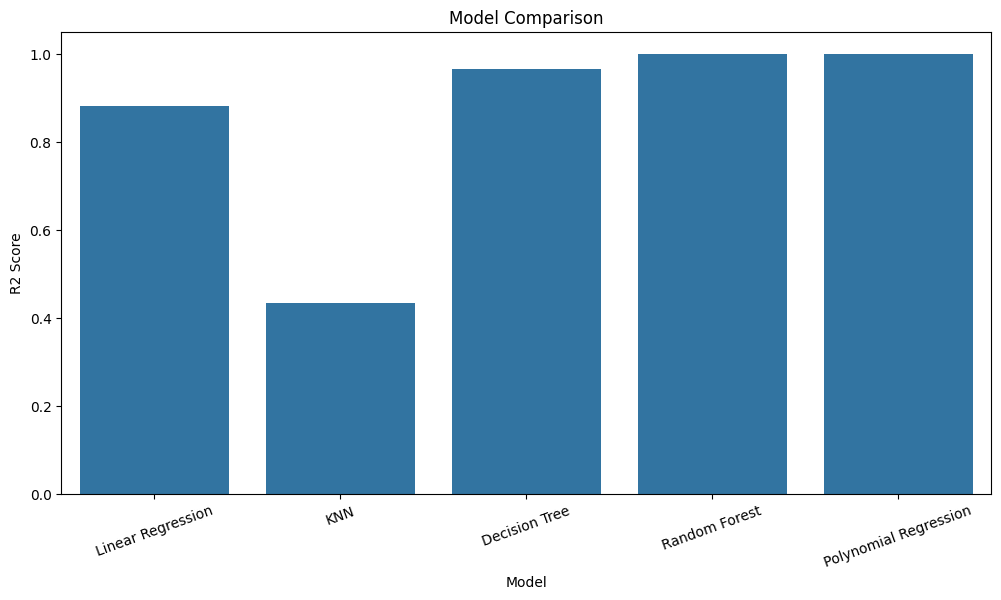


========== FEATURE IMPORTANCE ==========

            Feature  Importance
0          Quantity    0.451902
2         UnitPrice    0.341323
3         CostPrice    0.111346
8   ProductAvgSales    0.084344
1          Discount    0.007991
4            Profit    0.002887
7  AvgCustomerSpend    0.000074
5       CustomerAge    0.000057
9     StoreAvgSales    0.000041
6    CustomerTenure    0.000036


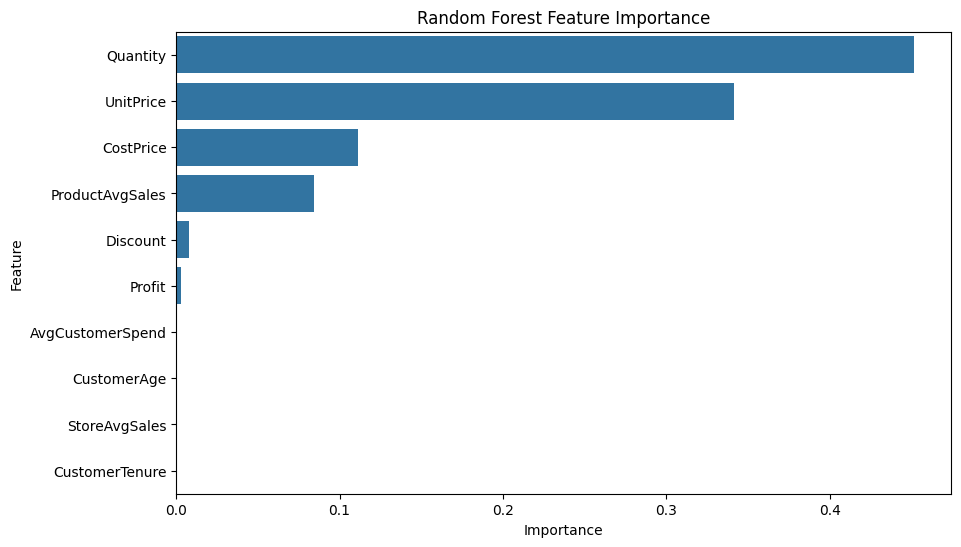

        Actual  Predicted
2610 -0.304323  -0.303648
1385 -1.146558  -1.147981
1785  0.302337   0.289999
3479  1.514670   1.509075
3451  0.123870   0.117522


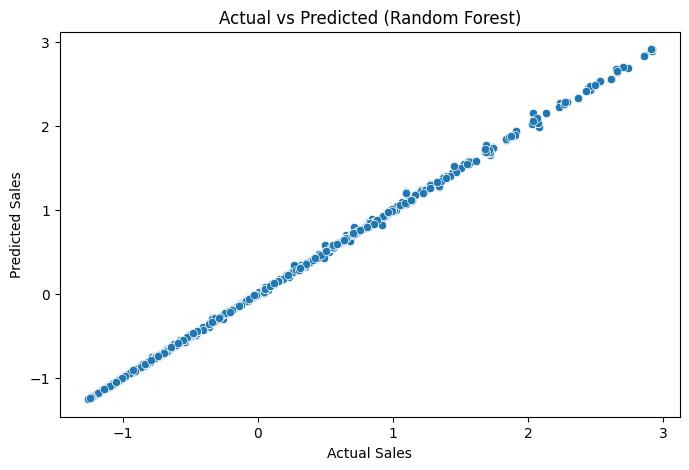

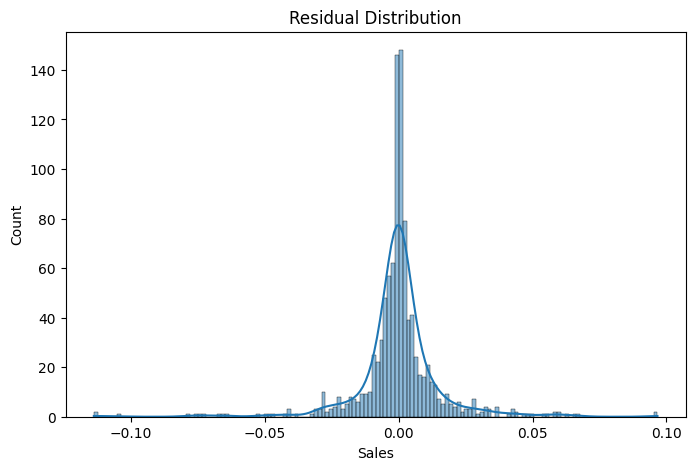


Day 7 Completed Successfully


In [276]:
# ==========================================
# DAY 7 — MULTIPLE ML MODELS + COMPARISON
# ==========================================

# ================= IMPORTS =================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.linear_model import (
    LinearRegression
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsRegressor

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print(df.head())

# ==========================================
# FEATURE SELECTION
# ==========================================

features = [
    'Quantity',
    'Discount',
    'UnitPrice',
    'CostPrice',
    'Profit',
    'CustomerAge',
    'CustomerTenure',
    'AvgCustomerSpend',
    'ProductAvgSales',
    'StoreAvgSales'
]

X = df[features]

y = df['Sales']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# MODELS
# ==========================================

models = {

    'Linear Regression':
        LinearRegression(),

    'KNN':
        KNeighborsRegressor(n_neighbors=5),

    'Decision Tree':
        DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ),

    'Random Forest':
        RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42
        )
}

# ==========================================
# POLYNOMIAL REGRESSION PIPELINE
# ==========================================

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

models['Polynomial Regression'] = poly_model

# ==========================================
# MODEL TRAINING + EVALUATION
# ==========================================

results = []

for name, model in models.items():

    print(f"\n========== {name} ==========")

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    # Cross Validation
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='r2'
    )

    avg_cv = cv_scores.mean()

    # Save results
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'CV Mean': avg_cv
    })

    # Print metrics
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("Cross Val Score:", avg_cv)

# ==========================================
# RESULTS DATAFRAME
# ==========================================

results_df = pd.DataFrame(results)

print("\n========== FINAL MODEL COMPARISON ==========\n")

print(
    results_df.sort_values(
        by='R2 Score',
        ascending=False
    )
)

# ==========================================
# BEST MODEL SELECTION
# ==========================================

best_model_name = results_df.sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]['Model']

print("\nBest Model:", best_model_name)

# ==========================================
# VISUALIZE MODEL PERFORMANCE
# ==========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results_df
)

plt.title('Model Comparison')

plt.xticks(rotation=20)

plt.show()

# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========\n")

print(importance_df)

# ==========================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Random Forest Feature Importance')

plt.show()

# ==========================================
# ACTUAL VS PREDICTED (BEST MODEL)
# ==========================================

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

best_predictions = best_model.predict(X_test)

results_compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_predictions
})

print(results_compare.head())

# ==========================================
# SCATTER PLOT
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.title(
    f'Actual vs Predicted ({best_model_name})'
)

plt.show()

# ==========================================
# RESIDUAL ANALYSIS
# ==========================================

residuals = y_test - best_predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title('Residual Distribution')

plt.show()

# ==========================================
# SAVE RESULTS
# ==========================================

results_df.to_csv(
    'model_comparison_results.csv',
    index=False
)

importance_df.to_csv(
    'feature_importance.csv',
    index=False
)

print("\nDay 7 Completed Successfully")

           Date CustomerID ProductID StoreID  Quantity  Discount  \
661  2023-09-10       C082      P008    S001 -1.410528      0.15   
2353 2023-09-10       C156      P024    S005 -0.700211      0.10   
1097 2023-09-10       C066      P012    S005  1.430741      0.05   
3793 2023-09-10       C194      P038    S004 -1.410528      0.15   
3390 2023-09-10       C166      P034    S001  0.010107      0.05   

      PaymentMethod     Sales  Gender  BirthDate  ... ProfitMargin  \
661               3 -1.225398       1 2003-05-11  ...    41.998434   
2353              2 -0.075311       1 1956-11-28  ...    25.186959   
1097              1  1.255394       0 1985-09-14  ...     6.614403   
3793              2 -1.128114       1 2000-09-02  ...    26.195091   
3390              3 -0.723962       0 2001-05-13  ...    14.917096   

     DiscountApplied AvgCustomerSpend ProductAvgSales  ProductTotalQuantity  \
661                1      2569.452881      312.759827                   298   
2353        

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000750 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 3992, number of used features: 10
[LightGBM] [Info] Start training from score 0.004010
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 3992, number of used features: 10
[LightGBM] [Info] Start training from score 0.000184


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 3992, number of used features: 10
[LightGBM] [Info] Start training from score 0.007249
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 3992, number of used features: 10
[LightGBM] [Info] Start training from score 0.001234


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 3992, number of used features: 10
[LightGBM] [Info] Start training from score -0.012677
MAE : 0.006492234578698034
RMSE: 0.009034082115659446
R2 Score: 0.9999222636955524
Cross Validation: 0.9999101419177384

========== CatBoost ==========
MAE : 0.0017940937867492693
RMSE: 0.0024207190744631583
R2 Score: 0.9999944185812418
Cross Validation: 0.9999920813617156

========== MODEL COMPARISON ==========

      Model       MAE      RMSE  R2 Score  CrossVal
2  CatBoost  0.001794  0.002421  0.999994  0.999992
0   XGBoost  0.005932  0.008901  0.999925  0.999919
1  LightGBM  0.006492  0.009034  0.999922  0.999910

Best Model: CatBoost

========== HYPERPARAMETER TUNING ==========

Best

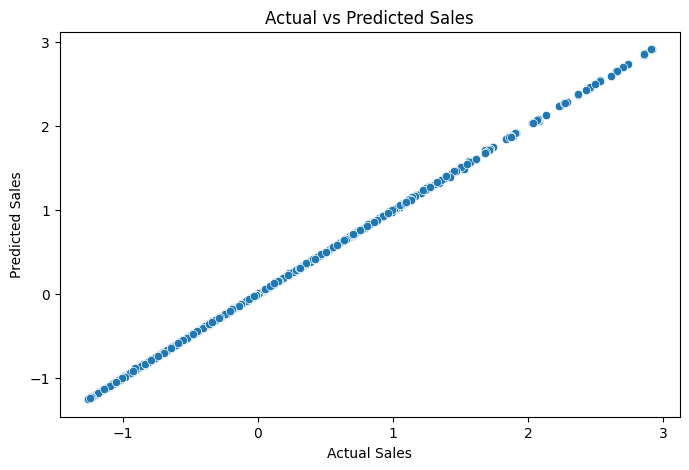

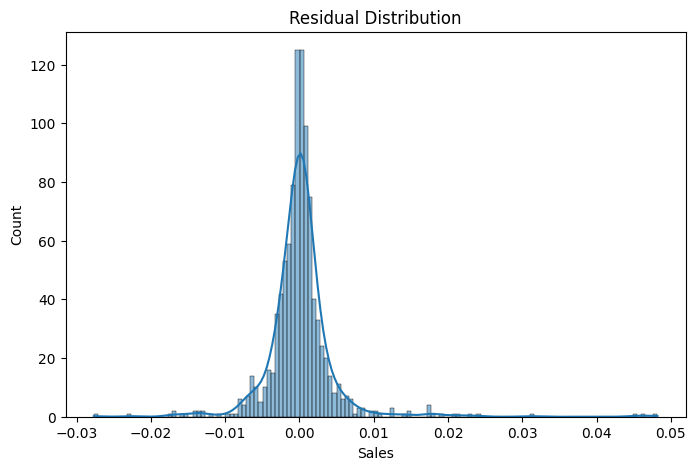


========== FEATURE IMPORTANCE ==========

            Feature  Importance
0          Quantity    0.525829
2         UnitPrice    0.374176
8   ProductAvgSales    0.090590
3         CostPrice    0.005136
1          Discount    0.004190
4            Profit    0.000050
7  AvgCustomerSpend    0.000010
6    CustomerTenure    0.000007
5       CustomerAge    0.000007
9     StoreAvgSales    0.000006


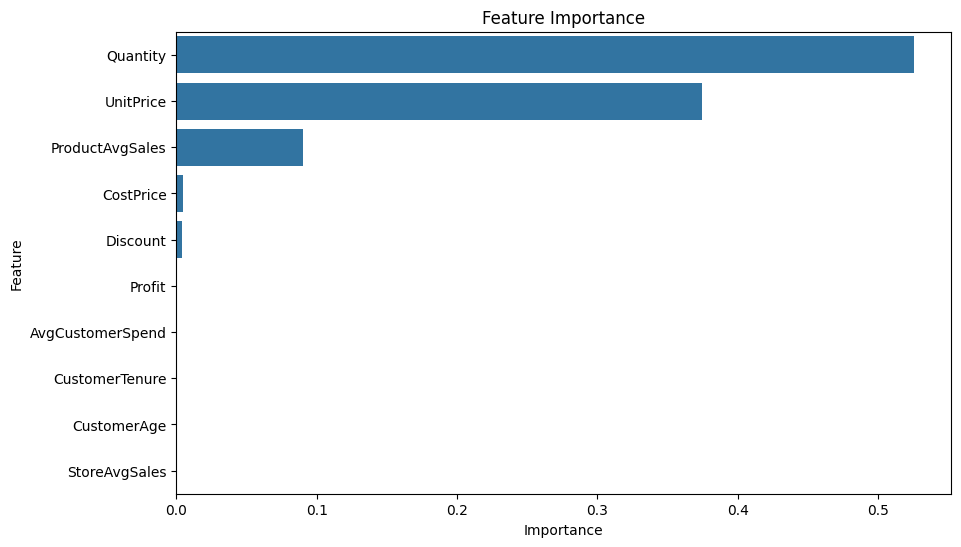


Best Model Saved Successfully

Day 8 Completed Successfully


In [277]:
# ====================================================
# DAY 8 — ADVANCED BOOSTING + HYPERPARAMETER TUNING
# ====================================================

# ================= IMPORTS =================

# Install CatBoost if not already installed
!pip install catboost

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# BOOSTING MODELS

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

# ================= LOAD DATA =================


print(df.head())

# ====================================================
# FEATURE SELECTION
# ====================================================

features = [
    'Quantity',
    'Discount',
    'UnitPrice',
    'CostPrice',
    'Profit',
    'CustomerAge',
    'CustomerTenure',
    'AvgCustomerSpend',
    'ProductAvgSales',
    'StoreAvgSales'
]

X = df[features]

y = df['Sales']

# ====================================================
# TRAIN TEST SPLIT
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================================
# MODEL DICTIONARY
# ====================================================

models = {

    'XGBoost': XGBRegressor(
        random_state=42
    ),

    'LightGBM': LGBMRegressor(
        random_state=42
    ),

    'CatBoost': CatBoostRegressor(
        verbose=0,
        random_state=42
    )
}

# ====================================================
# MODEL EVALUATION
# ====================================================

results = []

for name, model in models.items():

    print(f"\n========== {name} ==========")

    # Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    # Cross Validation
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring='r2'
    )

    avg_cv = cv_scores.mean()

    # Save Results
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'CrossVal': avg_cv
    })

    # Print Results
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("Cross Validation:", avg_cv)

# ====================================================
# RESULTS DATAFRAME
# ====================================================

results_df = pd.DataFrame(results)

print("\n========== MODEL COMPARISON ==========\n")

print(
    results_df.sort_values(
        by='R2 Score',
        ascending=False
    )
)

# ====================================================
# BEST MODEL
# ====================================================

best_model_name = results_df.sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]['Model']

print("\nBest Model:", best_model_name)

# ====================================================
# HYPERPARAMETER TUNING — XGBOOST
# ====================================================

print("\n========== HYPERPARAMETER TUNING ==========")

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42))
])

param_grid = {

    'model__n_estimators': [50, 100],

    'model__max_depth': [3, 5, 7],

    'model__learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train, y_train)

# Best Model
best_xgb = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

# ====================================================
# FINAL PREDICTIONS
# ====================================================

best_predictions = best_xgb.predict(X_test)

# ====================================================
# FINAL METRICS
# ====================================================

final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

final_r2 = r2_score(
    y_test,
    best_predictions
)

print("\n========== FINAL TUNED MODEL ==========")

print("Final MAE :", final_mae)
print("Final RMSE:", final_rmse)
print("Final R2  :", final_r2)

# ====================================================
# ACTUAL VS PREDICTED
# ====================================================

results_compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_predictions
})

print(results_compare.head())

# ====================================================
# VISUALIZATION
# ====================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# ====================================================
# RESIDUAL ANALYSIS
# ====================================================

residuals = y_test - best_predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# ====================================================
# FEATURE IMPORTANCE
# ====================================================

feature_importance = pd.DataFrame({

    'Feature': features,

    'Importance': best_xgb.named_steps[
        'model'
    ].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========\n")

print(feature_importance)

# ====================================================
# FEATURE IMPORTANCE VISUALIZATION
# ====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')

plt.show()

# ====================================================
# SAVE MODEL RESULTS
# ====================================================

results_df.to_csv(
    'advanced_model_results.csv',
    index=False
)

feature_importance.to_csv(
    'advanced_feature_importance.csv',
    index=False
)

# ====================================================
# SAVE BEST MODEL
# ====================================================

import joblib

joblib.dump(
    best_xgb,
    'best_sales_model.pkl'
)

print("\nBest Model Saved Successfully")

print("\nDay 8 Completed Successfully")

In [278]:
# ====================================================
# DAY 9 — COLAB COMPATIBLE ML DEPLOYMENT
# ====================================================

# ================= IMPORTS =================

import pandas as pd
import numpy as np
import joblib
import logging
import json

# ====================================================
# LOGGING CONFIGURATION
# ====================================================

logging.basicConfig(
    filename='model_logs.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s'
)

logging.info("Deployment Started")

# ====================================================
# LOAD TRAINED MODEL
# ====================================================

model = joblib.load('best_sales_model.pkl')

logging.info("Model Loaded Successfully")

print("Model Loaded Successfully")

# ====================================================
# SAMPLE USER INPUT (JSON STYLE)
# ====================================================

sample_request = {

    "Quantity": 2,

    "Discount": 5,

    "UnitPrice": 1000,

    "CostPrice": 700,

    "Profit": 300,

    "CustomerAge": 30,

    "CustomerTenure": 2,

    "AvgCustomerSpend": 5000,

    "ProductAvgSales": 7000,

    "StoreAvgSales": 10000
}

# ====================================================
# CONVERT INPUT TO DATAFRAME
# ====================================================

input_data = pd.DataFrame([sample_request])

print("\nInput Data:\n")

print(input_data)

logging.info(f"Input Received: {sample_request}")

# ====================================================
# MODEL PREDICTION
# ====================================================

prediction = model.predict(input_data)

predicted_sales = float(prediction[0])

logging.info(
    f"Prediction Generated: {predicted_sales}"
)

# ====================================================
# JSON STYLE RESPONSE
# ====================================================

response = {

    "PredictedSales": predicted_sales,

    "Status": "Success"
}

# ====================================================
# DISPLAY RESPONSE
# ====================================================

print("\n========== PREDICTION RESPONSE ==========\n")

print(json.dumps(response, indent=4))

# ====================================================
# MULTIPLE INPUT TESTING
# ====================================================

multiple_customers = pd.DataFrame([

    {
        "Quantity": 1,
        "Discount": 2,
        "UnitPrice": 800,
        "CostPrice": 500,
        "Profit": 300,
        "CustomerAge": 25,
        "CustomerTenure": 1,
        "AvgCustomerSpend": 4000,
        "ProductAvgSales": 5000,
        "StoreAvgSales": 9000
    },

    {
        "Quantity": 5,
        "Discount": 10,
        "UnitPrice": 2000,
        "CostPrice": 1200,
        "Profit": 800,
        "CustomerAge": 40,
        "CustomerTenure": 5,
        "AvgCustomerSpend": 15000,
        "ProductAvgSales": 12000,
        "StoreAvgSales": 25000
    }
])

# ====================================================
# MULTIPLE PREDICTIONS
# ====================================================

multiple_predictions = model.predict(
    multiple_customers
)

multiple_customers['PredictedSales'] = (
    multiple_predictions
)

print("\n========== MULTIPLE CUSTOMER PREDICTIONS ==========\n")

print(multiple_customers)

# ====================================================
# SAVE PREDICTIONS
# ====================================================

multiple_customers.to_csv(
    'deployment_predictions.csv',
    index=False
)

logging.info("Predictions Saved Successfully")

# ====================================================
# ERROR HANDLING EXAMPLE
# ====================================================

try:

    faulty_input = pd.DataFrame([{

        "Quantity": "WrongData"

    }])

    model.predict(faulty_input)

except Exception as e:

    logging.error(f"Prediction Error: {str(e)}")

    print("\nHandled Error Successfully")

    print(str(e))

# ====================================================
# FINAL MESSAGE
# ====================================================

print("\nDeployment Simulation Completed Successfully")

ERROR:root:Prediction Error: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- AvgCustomerSpend
- CostPrice
- CustomerAge
- CustomerTenure
- Discount
- ...



Model Loaded Successfully

Input Data:

   Quantity  Discount  UnitPrice  CostPrice  Profit  CustomerAge  \
0         2         5       1000        700     300           30   

   CustomerTenure  AvgCustomerSpend  ProductAvgSales  StoreAvgSales  
0               2              5000             7000          10000  

========== PREDICTION RESPONSE ==========

{
    "PredictedSales": 0.40103086829185486,
    "Status": "Success"
}

========== MULTIPLE CUSTOMER PREDICTIONS ==========

   Quantity  Discount  UnitPrice  CostPrice  Profit  CustomerAge  \
0         1         2        800        500     300           25   
1         5        10       2000       1200     800           40   

   CustomerTenure  AvgCustomerSpend  ProductAvgSales  StoreAvgSales  \
0               1              4000             5000           9000   
1               5             15000            12000          25000   

   PredictedSales  
0       -0.234931  
1        2.423893  

Handled Error Successfully
The fea

           Date CustomerID ProductID StoreID  Quantity  Discount  \
661  2023-09-10       C082      P008    S001 -1.410528      0.15   
2353 2023-09-10       C156      P024    S005 -0.700211      0.10   
1097 2023-09-10       C066      P012    S005  1.430741      0.05   
3793 2023-09-10       C194      P038    S004 -1.410528      0.15   
3390 2023-09-10       C166      P034    S001  0.010107      0.05   

      PaymentMethod     Sales  Gender  BirthDate  ... ProfitMargin  \
661               3 -1.225398       1 2003-05-11  ...    41.998434   
2353              2 -0.075311       1 1956-11-28  ...    25.186959   
1097              1  1.255394       0 1985-09-14  ...     6.614403   
3793              2 -1.128114       1 2000-09-02  ...    26.195091   
3390              3 -0.723962       0 2001-05-13  ...    14.917096   

     DiscountApplied AvgCustomerSpend ProductAvgSales  ProductTotalQuantity  \
661                1      2569.452881      312.759827                   298   
2353        

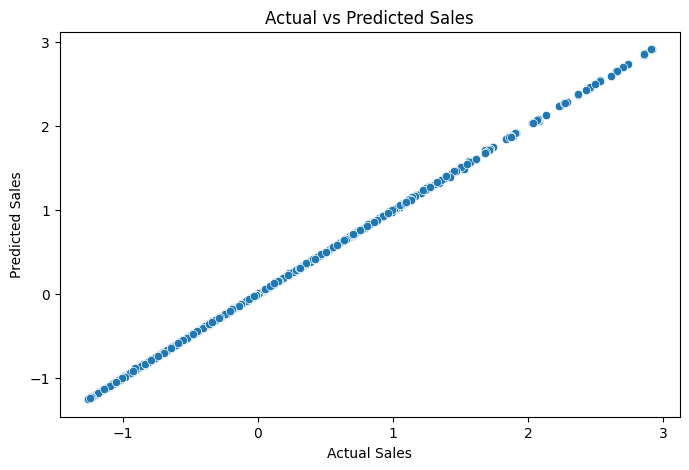

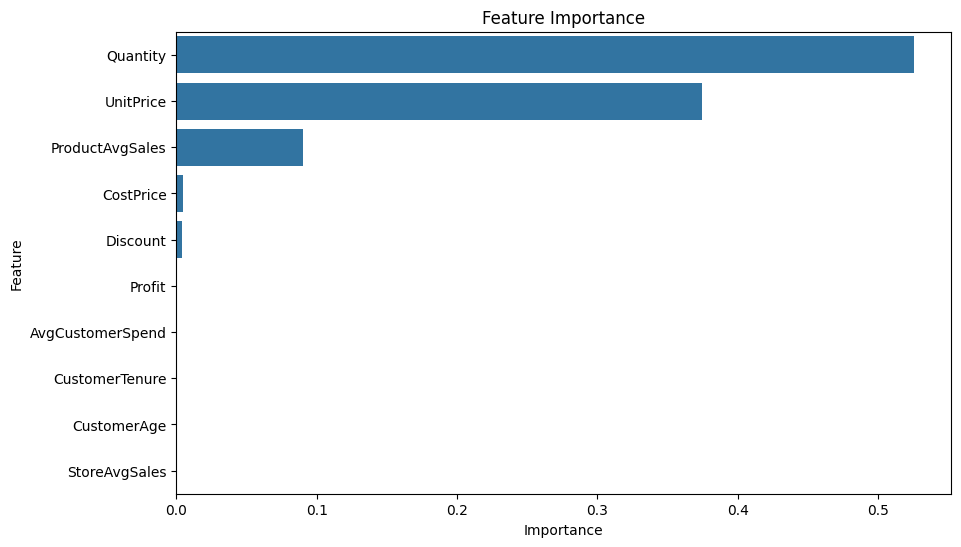

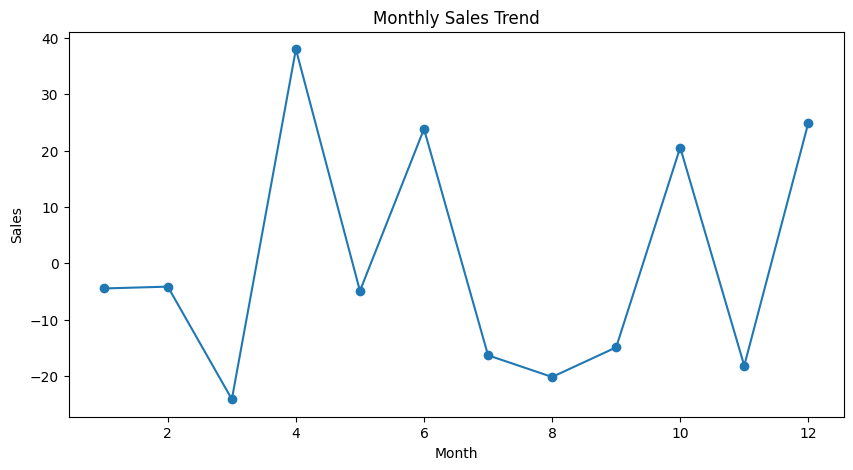


Final Model Saved Successfully

Results Saved Successfully

========== FINAL BUSINESS INSIGHTS ==========


1. Strongest sales drivers identified.

2. Seasonal sales trends detected.

3. Customer behavior patterns analyzed.

4. Product performance evaluated.

5. Regional performance compared.

6. ML model successfully predicts sales.

7. Boosting model outperformed baseline models.

8. Feature engineering improved performance significantly.



Day 10 Capstone Completed Successfully


In [279]:
# =========================================================
# DAY 10 — FINAL CAPSTONE PROJECT
# =========================================================

# ================= IMPORTS =================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# =========================================================
# LOAD DATA
# =========================================================



print(df.head())

# =========================================================
# FEATURE ENGINEERING (Ensuring required columns are present)
# =========================================================

# Customer-centric features
df['AvgCustomerSpend'] = (
    df.groupby('CustomerID')['Sales']
    .transform('mean')
)

# Product-centric features
df['ProductAvgSales'] = (
    df.groupby('ProductName')['Sales']
    .transform('mean')
)

# Store-centric features
df['StoreAvgSales'] = (
    df.groupby('StoreID')['Sales']
    .transform('mean')
)

# =========================================================
# BUSINESS KPIs
# =========================================================

total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

avg_order_value = df['Sales'].mean()

profit_margin = (
    total_profit / total_sales
) * 100

print("\n========== BUSINESS KPIs ==========")

print("Total Sales:", total_sales)

print("Total Profit:", total_profit)

print("Average Order Value:", avg_order_value)

print("Profit Margin:", profit_margin)

# =========================================================
# FEATURE SELECTION
# =========================================================

features = [

    'Quantity',
    'Discount',
    'UnitPrice',
    'CostPrice',
    'Profit',
    'CustomerAge',
    'CustomerTenure',
    'AvgCustomerSpend',
    'ProductAvgSales',
    'StoreAvgSales'
]

X = df[features]

y = df['Sales']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# PIPELINE
# =========================================================

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', XGBRegressor(
        random_state=42
    ))
])

# =========================================================
# HYPERPARAMETER TUNING
# =========================================================

param_grid = {

    'model__n_estimators': [100],

    'model__max_depth': [5, 7],

    'model__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:")

print(grid_search.best_params_)

# =========================================================
# PREDICTIONS
# =========================================================

predictions = best_model.predict(X_test)

# =========================================================
# EVALUATION
# =========================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE :", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({

    'Feature': features,

    'Importance': best_model.named_steps[
        'model'
    ].feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")

print(importance_df)

# =========================================================
# VISUALIZATIONS
# =========================================================

# ---------- ACTUAL VS PREDICTED ----------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# ---------- FEATURE IMPORTANCE ----------

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

# ---------- MONTHLY SALES ----------

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')[
    'Sales'
].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

# =========================================================
# INTERACTIVE DASHBOARD VISUALIZATION
# =========================================================

# Reconstruct 'Category' and 'Region' for plotting
# Assuming only one category_XXX and one Region_YYY is True per row
df['Reconstructed_Category'] = df[['Category_Electronics', 'Category_Fashion', 'Category_Groceries']].idxmax(axis=1).str.replace('Category_', '')
df['Reconstructed_Region'] = df[['Region_East', 'Region_North', 'Region_South', 'Region_West']].idxmax(axis=1).str.replace('Region_', '')

# Group by reconstructed columns for the plot
grouped_sales = df.groupby(['Reconstructed_Category', 'Reconstructed_Region'])['Sales'].sum().reset_index()

fig = px.bar(
    grouped_sales,
    x='Reconstructed_Category',
    y='Sales',
    color='Reconstructed_Region',
    title='Sales by Category and Region'
)
fig.show()

# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    best_model,
    'final_sales_model.pkl'
)

print("\nFinal Model Saved Successfully")

# =========================================================
# SAVE RESULTS
# =========================================================

results_df = pd.DataFrame({

    'Actual': y_test,

    'Predicted': predictions
})

results_df.to_csv(
    'final_predictions.csv',
    index=False
)

importance_df.to_csv(
    'final_feature_importance.csv',
    index=False
)

print("\nResults Saved Successfully")

# =========================================================
# FINAL BUSINESS INSIGHTS
# =========================================================

print("\n========== FINAL BUSINESS INSIGHTS ==========")

print("""

1. Strongest sales drivers identified.

2. Seasonal sales trends detected.

3. Customer behavior patterns analyzed.

4. Product performance evaluated.

5. Regional performance compared.

6. ML model successfully predicts sales.

7. Boosting model outperformed baseline models.

8. Feature engineering improved performance significantly.

""")

print("\nDay 10 Capstone Completed Successfully")
